# VIX Analog Calculator — OptionsDX SPX Data

Computes a VIX-style volatility index from local OptionsDX CSV/7z files using the CBOE VIX methodology:
1. Load the options chain for two expirations from OptionsDX data
2. Compute forward price via put-call parity
3. Compute variance integral over OTM options
4. Interpolate to a constant 30-day horizon

**OptionsDX wide format**: each row contains both call and put data for the same strike/expiry.
Midpoint = (bid + ask) / 2 is used as the option price.

In [21]:
from datetime import datetime, timezone, date
from pathlib import Path
import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import py7zr
from tqdm import tqdm
import yfinance as yf

In [3]:
# ── Configuration ────────────────────────────────────────────────────────────

# Path to your OptionsDX data — can contain .7z archives and/or extracted CSVs
DATA_DIR = Path("option_chains")
EXTRACT_DIR = Path("option_chains")

RISK_FREE_RATE = 0.05  # annualised, continuously compounded

# OptionsDX column names
COL_QUOTE_DATE   = "[QUOTE_DATE]"
COL_EXPIRE_DATE  = "[EXPIRE_DATE]"
COL_STRIKE       = "[STRIKE]"
COL_UNDERLYING   = "[UNDERLYING_LAST]"
COL_C_BID        = "[C_BID]"
COL_C_ASK        = "[C_ASK]"
COL_P_BID        = "[P_BID]"
COL_P_ASK        = "[P_ASK]"
COL_DTE          = "[DTE]"

## 1. Extract 7z archives (skip if already extracted)

In [4]:
def extract_all_7z(data_dir: Path, extract_dir: Path) -> None:
    """Extract all .7z files found under data_dir into extract_dir."""
    extract_dir.mkdir(parents=True, exist_ok=True)
    archives = list(data_dir.glob("**/*.7z"))
    if not archives:
        print("No .7z files found — assuming CSVs are already extracted.")
        return
    for archive in sorted(archives):
        print(f"Extracting {archive.name} …")
        with py7zr.SevenZipFile(archive, mode="r") as z:
            z.extractall(path=extract_dir)
    print(f"Done. CSVs are in {extract_dir}")

extract_all_7z(DATA_DIR, EXTRACT_DIR)

Extracting spx_eod_2018-uqawfl.7z …
Extracting spx_eod_2019-chxexe.7z …
Extracting spx_eod_2020-wh6jt7.7z …
Extracting spx_eod_2021-n4uqkm.7z …
Extracting spx_eod_2021q3-kgzold.7z …
Extracting spx_eod_2021q4-r3h0dx.7z …
Extracting spx_eod_2022q1-ff0r18.7z …
Extracting spx_eod_2022q2-bxgzw0.7z …
Extracting spx_eod_2022q3-1f2afi.7z …
Extracting spx_eod_2022q4-dmme3k.7z …
Extracting spx_eod_2023q1-cfph7w.7z …
Extracting spx_eod_2023q2-kdxt36.7z …
Extracting spx_eod_2023q3-w9b0jk.7z …
Extracting spx_eod_2023q4-ai4uc9.7z …
Done. CSVs are in option_chains


## 2. Load & cache all data

In [27]:
def load_optionsdx(csv_dir: Path) -> pd.DataFrame:
    """
    Load all OptionsDX CSVs from csv_dir (and DATA_DIR itself, in case
    some were pre-extracted there).
    Returns a single DataFrame with parsed date columns.
    """
    patterns = [
        str(csv_dir / "**" / "*.txt"),
        str(DATA_DIR / "**" / "*.txt"),
    ]
    files = sorted(set(f for p in patterns for f in glob.glob(p, recursive=True)))
    if not files:
        raise FileNotFoundError(
            f"No TXT files found under {csv_dir} or {DATA_DIR}. "
            "Check DATA_DIR / EXTRACT_DIR."
        )
    print(f"Loading {len(files)} TXT file(s) …")
    chunks = []
    for f in tqdm(files):
        df = pd.read_csv(
            f,
            parse_dates=[COL_QUOTE_DATE, COL_EXPIRE_DATE],
            low_memory=False,
            skipinitialspace=True,
        )
        # Normalise column names (strip whitespace)
        df.columns = df.columns.str.strip()
        chunks.append(df)
    data = pd.concat(chunks, ignore_index=True)
    print(f"Loaded {len(data):,} rows spanning "
          f"{data[COL_QUOTE_DATE].min().date()} – {data[COL_QUOTE_DATE].max().date()}")
    return data

raw = load_optionsdx(EXTRACT_DIR)
print(raw)

Loading 72 TXT file(s) …


100%|██████████████████████████████████████████████████████████████████████████| 72/72 [00:32<00:00,  2.23it/s]


Loaded 10,763,286 rows spanning 2018-01-02 – 2023-12-29
          [QUOTE_UNIXTIME]  [QUOTE_READTIME] [QUOTE_DATE]  [QUOTE_TIME_HOURS]  \
0               1514926800  2018-01-02 16:00   2018-01-02                16.0   
1               1514926800  2018-01-02 16:00   2018-01-02                16.0   
2               1514926800  2018-01-02 16:00   2018-01-02                16.0   
3               1514926800  2018-01-02 16:00   2018-01-02                16.0   
4               1514926800  2018-01-02 16:00   2018-01-02                16.0   
...                    ...               ...          ...                 ...   
10763281        1703883600  2023-12-29 16:00   2023-12-29                16.0   
10763282        1703883600  2023-12-29 16:00   2023-12-29                16.0   
10763283        1703883600  2023-12-29 16:00   2023-12-29                16.0   
10763284        1703883600  2023-12-29 16:00   2023-12-29                16.0   
10763285        1703883600  2023-12-29 16:00   2023-1

## 3. Chain builder from local data

In [6]:
def build_chain_from_df(
    df: pd.DataFrame,
    as_of_date: str | date,
    expiration_date: str | date,
    strike_window_pct: float | None = None,
) -> list[tuple[float, float | None, float | None]]:
    """
    Extract the options chain for a single (quote_date, expiration_date) pair
    from an OptionsDX wide-format DataFrame.

    Returns a list of (strike, call_mid, put_mid) tuples, sorted by strike.
    Midpoints are (bid + ask) / 2; None if both bid and ask are zero/NaN.
    """
    as_of = pd.Timestamp(as_of_date)
    expiry = pd.Timestamp(expiration_date)

    mask = (
        (df[COL_QUOTE_DATE].dt.normalize() == as_of.normalize()) &
        (df[COL_EXPIRE_DATE].dt.normalize() == expiry.normalize())
    )
    subset = df[mask].copy()

    if subset.empty:
        raise ValueError(
            f"No data found for quote_date={as_of_date}, expiration={expiration_date}. "
            f"Available expirations on that date: "
            f"{sorted(df[df[COL_QUOTE_DATE].dt.normalize()==as_of.normalize()][COL_EXPIRE_DATE].dt.date.unique())}"
        )

    # Optionally filter to a strike window around the underlying
    if strike_window_pct is not None:
        spot = subset[COL_UNDERLYING].iloc[0]
        lo, hi = spot * (1 - strike_window_pct), spot * (1 + strike_window_pct)
        subset = subset[(subset[COL_STRIKE] >= lo) & (subset[COL_STRIKE] <= hi)]

    def mid(bid_col, ask_col, row):
        b, a = row[bid_col], row[ask_col]
        if pd.isna(b) or pd.isna(a) or (b <= 0 and a <= 0):
            return None
        # If one side is zero, use the other
        if b <= 0:
            return a
        if a <= 0:
            return b
        return (b + a) / 2

    chain = []
    for _, row in subset.iterrows():
        K = row[COL_STRIKE]
        c_mid = mid(COL_C_BID, COL_C_ASK, row)
        p_mid = mid(COL_P_BID, COL_P_ASK, row)
        chain.append((K, c_mid, p_mid))

    chain.sort(key=lambda x: x[0])
    return chain


def available_expirations(df: pd.DataFrame, as_of_date: str | date) -> list[date]:
    """List all expiration dates available in the data for a given quote date."""
    as_of = pd.Timestamp(as_of_date)
    mask = df[COL_QUOTE_DATE].dt.normalize() == as_of.normalize()
    return sorted(df[mask][COL_EXPIRE_DATE].dt.date.unique())

## 4. VIX math

In [7]:
def forward_price(chain: list[tuple], r: float, tau: float) -> float:
    """Forward price via put-call parity at the strike where |C - P| is minimised."""
    best_strike, best_diff, best_c, best_p = None, float("inf"), None, None
    for K, c, p in chain:
        if c is not None and p is not None:
            diff = abs(c - p)
            if diff < best_diff:
                best_strike, best_diff, best_c, best_p = K, diff, c, p
    if best_strike is None:
        raise ValueError("No strikes with both call and put prices found.")
    return best_strike + np.exp(r * tau) * (best_c - best_p)


def chain_lookup(chain: list[tuple], K: float):
    for strike, call_mid, put_mid in chain:
        if strike == K:
            return call_mid, put_mid
    return None, None


def compute_variance(chain: list[tuple], F: float, r: float, tau: float) -> tuple[float, float]:
    """CBOE VIX variance integral over OTM options."""
    strikes = sorted(set(c[0] for c in chain))
    K0 = max(k for k in strikes if k < F)  # largest strike below F

    total = 0.0
    n = len(strikes)
    for i, K in enumerate(strikes):
        call_mid, put_mid = chain_lookup(chain, K)

        if K < K0:
            Q = put_mid
        elif K > K0:
            Q = call_mid
        else:  # K == K0: average of call and put
            Q = (call_mid + put_mid) / 2 if (call_mid and put_mid) else (call_mid or put_mid)

        if Q is None:
            continue

        if i == 0:
            dK = strikes[1] - strikes[0]
        elif i == n - 1:
            dK = strikes[-1] - strikes[-2]
        else:
            dK = (strikes[i + 1] - strikes[i - 1]) / 2

        total += (dK / K**2) * np.exp(r * tau) * Q

    variance = (2 / tau) * total - (1 / tau) * ((F / K0) - 1) ** 2
    return variance, K0

## 5. Main VIX calculation

In [8]:
def calculate_vix(
    df: pd.DataFrame,
    as_of_date: str,
    near_expiration: str,
    next_expiration: str,
    strike_window_pct: float | None = 0.10,
    r: float = RISK_FREE_RATE,
    quiet: bool = False,
) -> float:
    """
    Calculate VIX-style implied volatility from OptionsDX data.

    Parameters
    ----------
    df               : full OptionsDX DataFrame (from load_optionsdx)
    as_of_date       : the pricing date, e.g. "2024-01-12"
    near_expiration  : near-term expiration, e.g. "2024-01-19"
    next_expiration  : next-term expiration, e.g. "2024-02-16"
    strike_window_pct: fraction around spot to include (None = all strikes)
    r                : risk-free rate (continuously compounded, annualised)
    """
    as_of_dt = pd.Timestamp(as_of_date).replace(tzinfo=timezone.utc)

    T1 = (pd.Timestamp(near_expiration, tz="UTC") - as_of_dt).total_seconds() / (365 * 86400)
    T2 = (pd.Timestamp(next_expiration,  tz="UTC") - as_of_dt).total_seconds() / (365 * 86400)
    T30 = 30 / 365

    if T1 <= 0 or T2 <= 0:
        raise ValueError("Expiration dates must be after as_of_date.")

    chain1 = build_chain_from_df(df, as_of_date, near_expiration, strike_window_pct)
    chain2 = build_chain_from_df(df, as_of_date, next_expiration,  strike_window_pct)

    F1 = forward_price(chain1, r, T1)
    F2 = forward_price(chain2, r, T2)

    var1, K0_1 = compute_variance(chain1, F1, r, T1)
    var2, K0_2 = compute_variance(chain2, F2, r, T2)

    if not quiet:
        print(f"Near  ({near_expiration}): T={T1*365:.1f}d  F={F1:.2f}  K0={K0_1}  var={var1:.6f}")
        print(f"Next  ({next_expiration}): T={T2*365:.1f}d  F={F2:.2f}  K0={K0_2}  var={var2:.6f}")

    N1, N2, N30 = T1 * 365, T2 * 365, 30
    weighted = (
        T1 * var1 * (N2 - N30) / (N2 - N1)
        + T2 * var2 * (N30 - N1) / (N2 - N1)
    )
    vix = 100 * np.sqrt(weighted * 365 / 30)
    return vix

## 6. Rolling VIX across all dates in the dataset

In [9]:
def auto_select_expirations(
    expirations: list[date], as_of: date, target_dte: int = 30
) -> tuple[date, date] | None:
    """
    Auto-select near/next expirations that straddle target_dte.
    Returns None if not possible.
    """
    as_of_ts = pd.Timestamp(as_of)
    dtes = [(e, (pd.Timestamp(e) - as_of_ts).days) for e in expirations]
    # Must have at least 7 DTE
    dtes = [(e, d) for e, d in dtes if d >= 7]
    below = [(e, d) for e, d in dtes if d <= target_dte]
    above = [(e, d) for e, d in dtes if d > target_dte]
    if not below or not above:
        return None
    near = max(below, key=lambda x: x[1])[0]   # closest below 30
    nxt  = min(above, key=lambda x: x[1])[0]   # closest above 30
    return near, nxt


def rolling_vix(
    df: pd.DataFrame,
    strike_window_pct: float = 0.10,
    r: float = RISK_FREE_RATE,
) -> pd.DataFrame:
    """Compute VIX for every trading day in the dataset."""
    all_dates = sorted(df[COL_QUOTE_DATE].dt.date.unique())
    results = []
    for as_of in tqdm(all_dates):
        expiries = available_expirations(df, as_of)
        pair = auto_select_expirations(expiries, as_of)
        if pair is None:
            continue
        near, nxt = pair
        try:
            vix = calculate_vix(
                df, str(as_of), str(near), str(nxt),
                strike_window_pct=strike_window_pct, r=r,
                quiet=True,
            )
            results.append({"date": as_of, "near": near, "next": nxt, "vix": vix})
        except Exception as e:
            print(f"Skipping {as_of}: {e}")

    return pd.DataFrame(results).set_index("date")

vix_series = rolling_vix(raw)

 67%|██████████████████████████████████████████████▉                       | 1006/1500 [12:29<06:24,  1.28it/s]

Skipping 2022-01-17: No strikes with both call and put prices found.


 69%|████████████████████████████████████████████████                      | 1031/1500 [12:48<05:37,  1.39it/s]

Skipping 2022-02-21: No strikes with both call and put prices found.


 71%|█████████████████████████████████████████████████▉                    | 1070/1500 [13:16<05:20,  1.34it/s]

Skipping 2022-04-15: No strikes with both call and put prices found.


 83%|██████████████████████████████████████████████████████████▏           | 1247/1500 [15:30<03:07,  1.35it/s]

Skipping 2022-12-26: No strikes with both call and put prices found.


100%|██████████████████████████████████████████████████████████████████████| 1500/1500 [18:40<00:00,  1.34it/s]


## 7. Calculate Market Volatility from SPX

In [41]:
def realized_volatility() -> pd.DataFrame:
    spx = yf.download("^GSPC", start="2018-01-01", end="2024-01-01")
    log_returns = np.log(spx["Close"] / spx["Close"].shift(1))
    realized_vol = log_returns.rolling(window=21).std() * np.sqrt(252) * 100
    realized_vol_forward = realized_vol.shift(-21)
    return realized_vol_forward

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


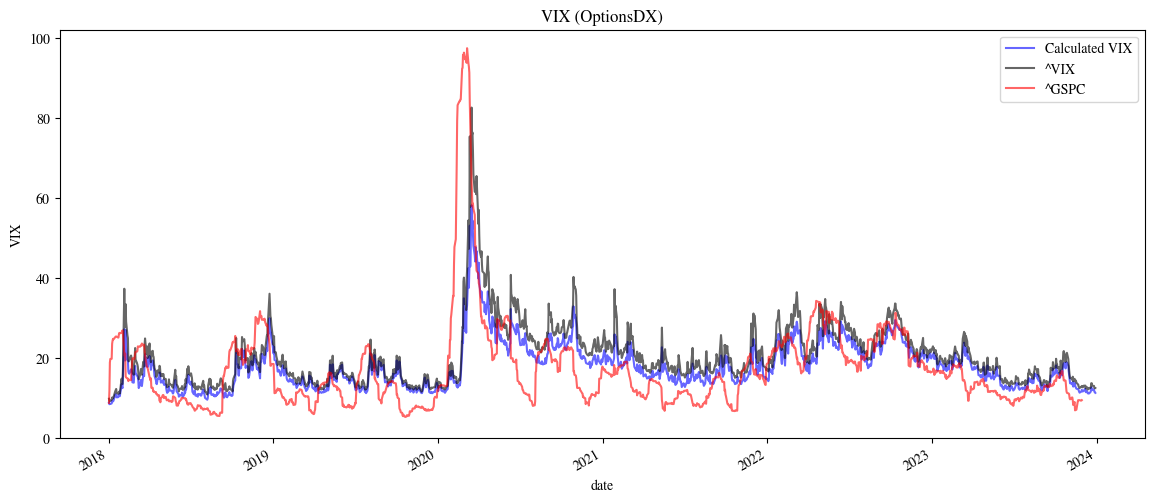

In [45]:
vix_data = yf.download("^VIX", start="2018-01-01", end="2024-01-01")
vol = realized_volatility()

ax = vix_series["vix"].plot(title="VIX (OptionsDX)", figsize=(14, 6), ylabel="VIX",
                           color="b", lw=1.5, alpha=0.6, label="Calculated VIX")
vix_data["Close"].plot(ax=ax, color="k", lw=1.5, alpha=0.6)
vol.plot(ax=ax, color="r", lw=1.5, alpha=0.6)
ax.set_ylim(bottom=0)
plt.legend()
vix_series.to_csv("vix_calc.csv")
vix_data["Close"].to_csv("vix_true.csv")
vol.to_csv("realized_vol.csv")